# 5.8 veces más células en la zona inflamada del cerebro

Sin cirugía. Sin abrir el cráneo. Solo un hidrogel inyectado en la sangre que se queda donde hay inflamación, y luz infrarroja desde afuera para encenderlo.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2025-11-05-implantes-cerebrales-circulatronics/notebook.ipynb)

**Paper**: [Yadav et al. *Nature Biotechnology* (2025)](https://doi.org/10.1038/s41587-025-02809-3)  ·  **Datos**: Source Data MOESM3 (29 sheets, ~9 MB)

**Video corto del canal**: pendiente de publicación.

## ¿Qué hicieron?

El equipo de Princeton diseñó **células híbridas**: hicieron crecer una capa de proteína conductora alrededor de células inmunes (macrófagos), y dentro encapsularon **fotodiodos del tamaño de bacterias** (~1 µm). Las inyectaron en la sangre de ratones con una zona inflamada en el cerebro.

Los macrófagos hacen lo que siempre hacen — **migran a la inflamación**. Los fotodiodos, encendidos con luz infrarroja desde fuera del cráneo, generan los pulsos eléctricos. Sin tornillos, sin electrodos rígidos, sin abrir el cráneo.

Veamos qué tanto realmente se concentran ahí — y qué tanto la luz logra llegar a través del hueso.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_HIBRIDOS_LUZ = '#DC2626'       # rojo: condición ganadora
COLOR_HIBRIDOS_NOLUZ = '#7C3AED'     # violeta: híbridos sin luz
COLOR_CELULAS_LUZ = '#059669'        # emerald: células solas con luz
COLOR_CONTROL = '#BBBBBB'            # gris: control completo
COLOR_DATOS = '#2563EB'              # azul CaM
COLOR_REFERENCIA = '#D97706'         # ámbar referencia
FUENTE = 'Fuente: Yadav et al. (2025), Nature Biotechnology | Datos: Source Data MOESM3 — DOI 10.1038/s41587-025-02809-3'

# Imports
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Carga de los 3 datasets
df_bio = pd.read_csv('datos/biodistribucion_fig4f.csv')
df_pers = pd.read_csv('datos/persistencia_fig5f.csv')
df_pv = pd.read_csv('datos/pv_power_fig2g.csv')

print(f"Biodistribución (Fig 4f): {len(df_bio)} mediciones, {df_bio['condicion'].nunique()} condiciones")
print(f"Persistencia (Fig 5f):   {len(df_pers)} mediciones, {df_pers['tiempo'].nunique()} tiempos")
print(f"PV power (Fig 2g):       {len(df_pv)} intensidades de luz")

Biodistribución (Fig 4f): 18 mediciones, 4 condiciones
Persistencia (Fig 5f):   11 mediciones, 4 tiempos
PV power (Fig 2g):       11 intensidades de luz


## Aquí está.

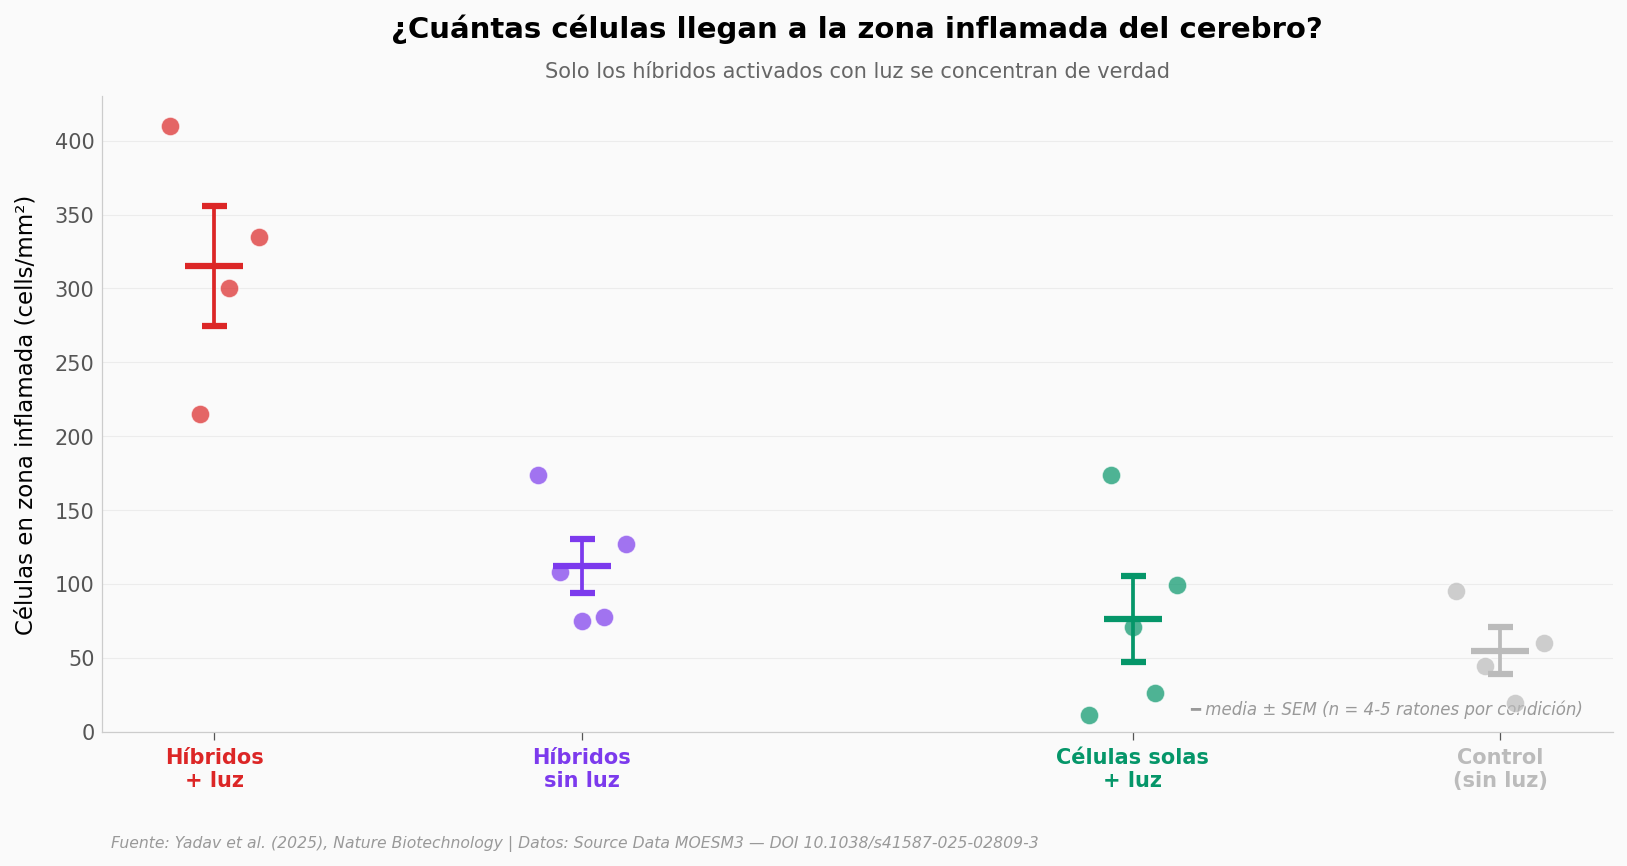

In [2]:
# Gráfica HERO: cuánto se concentra cada condición en la zona inflamada
fig, ax = plt.subplots(figsize=(13, 5.5))

condiciones = [
    ('hibridos_con_luz', 'Híbridos + luz', COLOR_HIBRIDOS_LUZ, 0),
    ('hibridos_sin_luz', 'Híbridos sin luz', COLOR_HIBRIDOS_NOLUZ, 1),
    ('celulas_solas_con_luz', 'Células solas + luz', COLOR_CELULAS_LUZ, 2.5),
    ('celulas_solas_sin_luz', 'Control (células sin luz)', COLOR_CONTROL, 3.5),
]

np.random.seed(42)
for nombre, etiqueta, color, pos in condiciones:
    vals = df_bio[df_bio['condicion'] == nombre]['celulas_por_mm2'].values
    n = len(vals)
    x_strip = np.linspace(pos - 0.12, pos + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=80, alpha=0.7,
               edgecolors='white', linewidths=0.6, zorder=5)
    media = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, media, yerr=sem, fmt='_', color=color,
                markersize=28, markeredgewidth=3,
                capsize=6, capthick=1.5, zorder=6)

ax.set_xticks([0, 1, 2.5, 3.5])
ax.set_xticklabels(['Híbridos\n+ luz', 'Híbridos\nsin luz',
                    'Células solas\n+ luz', 'Control\n(sin luz)'],
                   fontsize=10, fontweight='bold')
for tick, (_, _, color, _) in zip(ax.get_xticklabels(), condiciones):
    tick.set_color(color)

ax.set_ylabel('Células en zona inflamada (cells/mm²)', fontsize=11)
ax.set_title('¿Cuántas células llegan a la zona inflamada del cerebro?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Solo los híbridos activados con luz se concentran de verdad',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM (n = 4-5 ratones por condición)',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')
ax.set_ylim(bottom=0)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/biodistribucion_4condiciones.png', dpi=200, bbox_inches='tight')
plt.show()

La diferencia entre condiciones es enorme. Los híbridos con luz se acumulan a una densidad que ninguna otra condición se acerca: alrededor de **315 cells/mm²** en la zona inflamada, frente a **55** del control completo. La proporción es de **5.8 veces más**.

Lo que llama la atención: los híbridos sin luz también suben respecto al control (los macrófagos migran solos hacia donde hay inflamación, sin necesidad de luz), pero quedan tres veces por debajo de los híbridos encendidos. Y las células solas con luz se quedan donde el control — sin la coraza electrónica, los fotodiodos no llegan, y las células tampoco se concentran más. La activación importa, pero solo si hay con qué activar.

¿Cuán robusto es esto? El tamaño del efecto contra el control completo es **Cohen's d = 4.24** — la convención llama "grande" a cualquier d > 0.8. Y el test no paramétrico (Mann-Whitney U) da **p = 0.029**.

> **Caveat:** n pequeño (4-5 ratones por grupo). Es lo típico en estudios de neuromodulación in vivo, pero limita la potencia estadística — un solo outlier puede mover la media.

## ¿Cuánto duran ahí?

Si las células híbridas se descomponen en una semana, la idea no sirve. El equipo midió **densidad de SWEDs** (los fotodiodos individuales) en la zona inflamada a 1 día, 1 semana, 1 mes y **6 meses** después de la inyección. Veamos qué pasó.

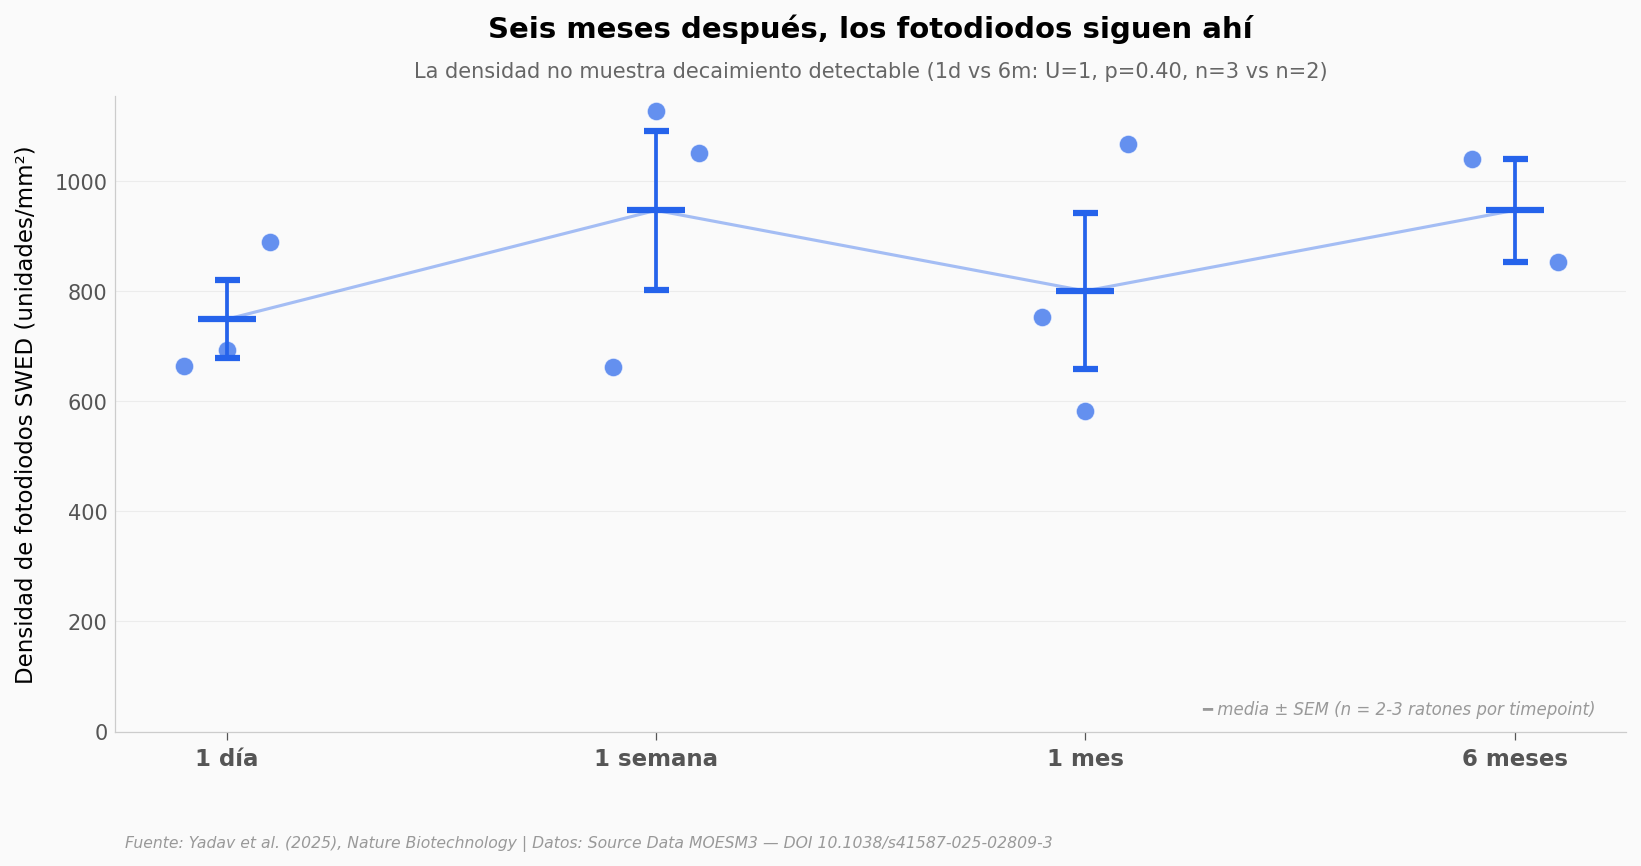

In [3]:
# Persistencia: SWEDs/mm² en 4 timepoints
fig, ax = plt.subplots(figsize=(13, 5.5))

orden = ['1_dia', '1_semana', '1_mes', '6_meses']
etiquetas = ['1 día', '1 semana', '1 mes', '6 meses']
posiciones = np.arange(len(orden))

np.random.seed(42)
medias = []
for i, t in enumerate(orden):
    vals = df_pers[df_pers['tiempo'] == t]['sweds_por_mm2'].values
    n = len(vals)
    x_strip = np.linspace(i - 0.10, i + 0.10, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=COLOR_DATOS, s=80, alpha=0.7,
               edgecolors='white', linewidths=0.6, zorder=5)
    m = vals.mean()
    medias.append(m)
    sem = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0
    ax.errorbar(i, m, yerr=sem, fmt='_', color=COLOR_DATOS,
                markersize=28, markeredgewidth=3,
                capsize=6, capthick=1.5, zorder=6)

# Línea conectando las medias
ax.plot(posiciones, medias, color=COLOR_DATOS, linewidth=1.5, alpha=0.4, zorder=3)

ax.set_xticks(posiciones)
ax.set_xticklabels(etiquetas, fontsize=11, fontweight='bold')
ax.set_ylabel('Densidad de fotodiodos SWED (unidades/mm²)', fontsize=11)
ax.set_title('Seis meses después, los fotodiodos siguen ahí',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La densidad no muestra decaimiento detectable (1d vs 6m: U=1, p=0.40, n=3 vs n=2)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM (n = 2-3 ratones por timepoint)',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')
ax.set_ylim(bottom=0)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/persistencia_6meses.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y la luz infrarroja realmente atraviesa el cráneo?

Esa es la pregunta que sostiene todo el sistema. Si el hueso bloquea demasiado, los fotodiodos nunca se activan. El equipo midió la potencia eléctrica generada por los SWEDs **con y sin un cráneo de ratón** colocado en el camino, a once intensidades distintas de luz NIR (cerca-infrarroja, 980 nm).

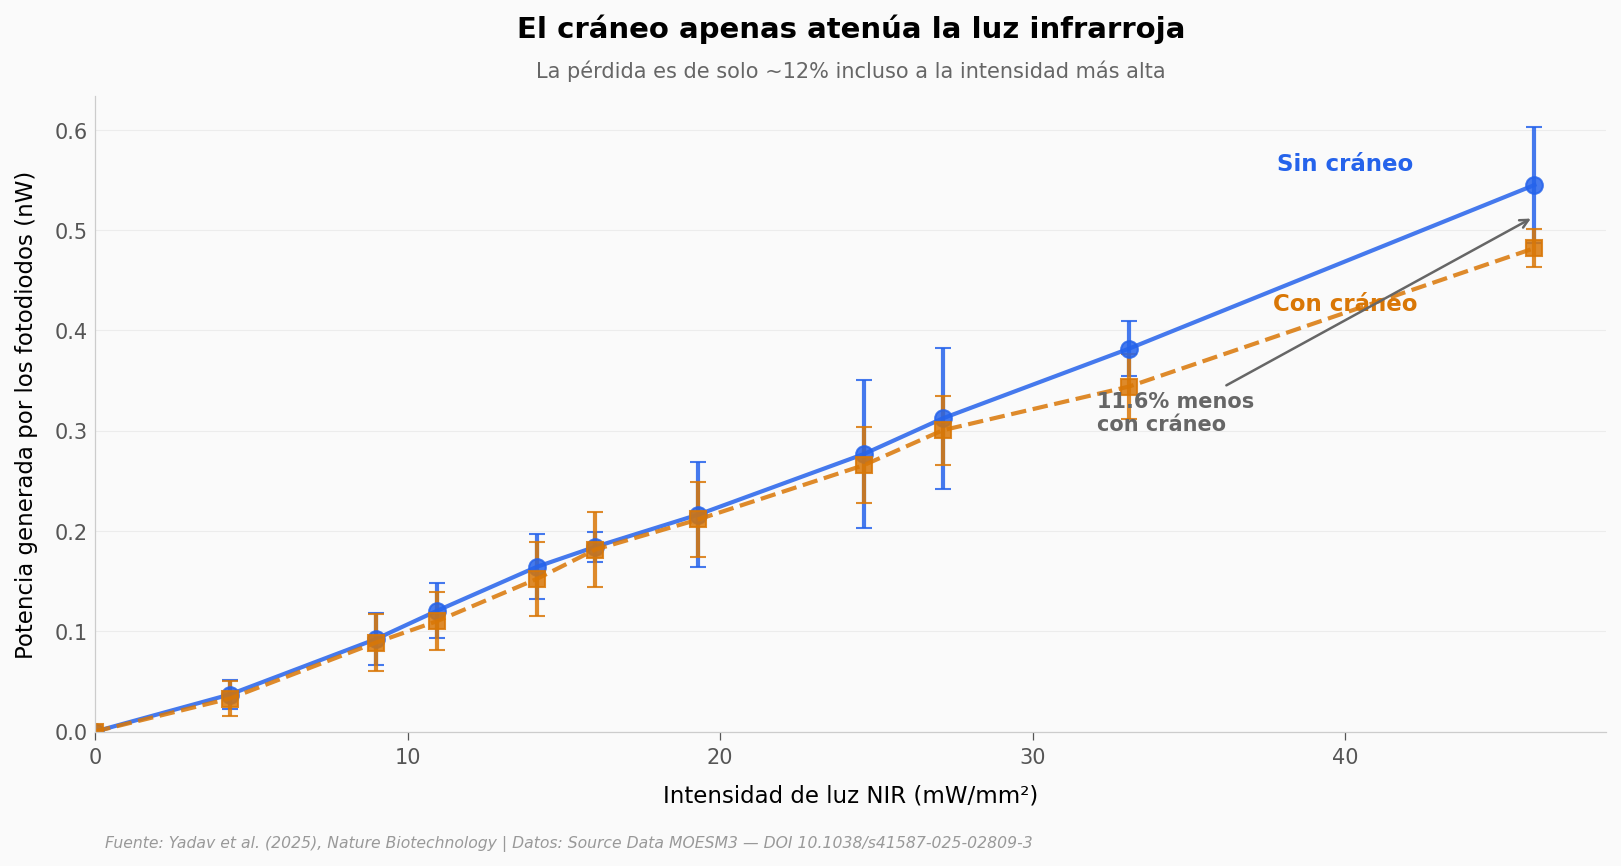

In [4]:
# Potencia de los fotodiodos vs intensidad de luz, con/sin cráneo
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.errorbar(df_pv['intensidad_mw_mm2'], df_pv['power_sin_craneo_nw_mean'],
            yerr=df_pv['power_sin_craneo_nw_std'],
            fmt='o-', color=COLOR_DATOS, linewidth=2, markersize=8,
            capsize=4, alpha=0.85, label='Sin cráneo')
ax.errorbar(df_pv['intensidad_mw_mm2'], df_pv['power_con_craneo_nw_mean'],
            yerr=df_pv['power_con_craneo_nw_std'],
            fmt='s--', color=COLOR_REFERENCIA, linewidth=2, markersize=8,
            capsize=4, alpha=0.85, label='Con cráneo de ratón')

# Inline labels en lugar de legend box
ax.text(40, 0.56, 'Sin cráneo', fontsize=11, fontweight='bold',
        color=COLOR_DATOS, ha='center')
ax.text(40, 0.42, 'Con cráneo', fontsize=11, fontweight='bold',
        color=COLOR_REFERENCIA, ha='center')

# Anotación de la diferencia a intensidad máxima
max_int = df_pv['intensidad_mw_mm2'].max()
sin_max = df_pv['power_sin_craneo_nw_mean'].iloc[-1]
con_max = df_pv['power_con_craneo_nw_mean'].iloc[-1]
red_pct = (sin_max - con_max) / sin_max * 100
ax.annotate(f'{red_pct:.1f}% menos\ncon cráneo',
            xy=(max_int, (sin_max + con_max)/2),
            xytext=(max_int - 14, 0.3),
            fontsize=10, fontweight='bold', color='#666666',
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2))

ax.set_xlabel('Intensidad de luz NIR (mW/mm²)', fontsize=11)
ax.set_ylabel('Potencia generada por los fotodiodos (nW)', fontsize=11)
ax.set_title('El cráneo apenas atenúa la luz infrarroja',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'La pérdida es de solo ~12% incluso a la intensidad más alta',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend().set_visible(False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/pv_power_craneo.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan grande es el efecto, en realidad?

Cohen's d = 4.24 suena enorme. Pero con n = 4-5 por grupo, conviene preguntarse qué tan robusto es ese número. Una forma directa: re-muestrear los datos miles de veces y ver dónde cae la distribución del estadístico.

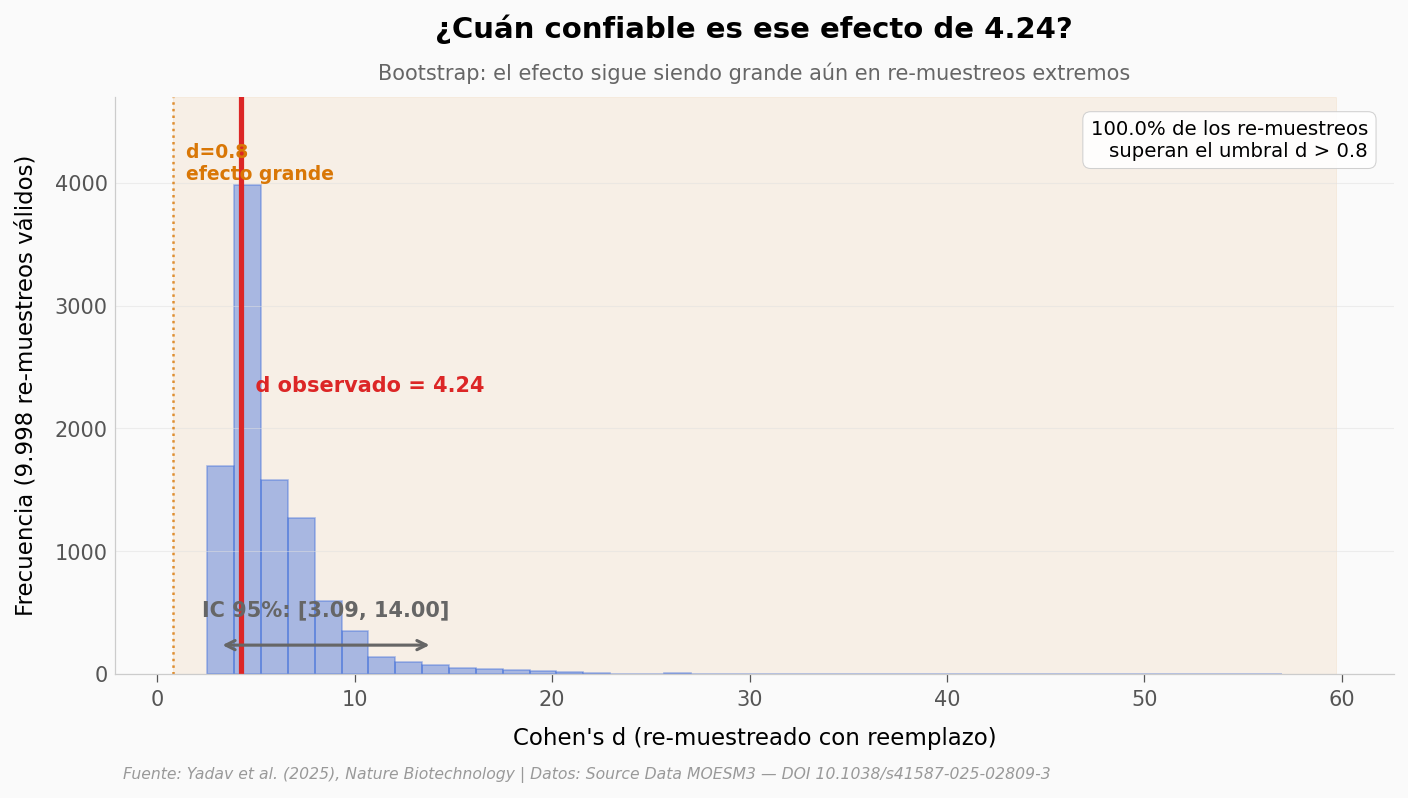

d observado: 4.24
IC 95% bootstrap: [3.09, 14.00]
% bootstraps con d > 0.8 (efecto grande): 100.0%


In [5]:
# Bootstrap de Cohen's d: ¿qué tan robusto es 4.24?
hibridos_luz = df_bio[df_bio['condicion'] == 'hibridos_con_luz']['celulas_por_mm2'].values
control = df_bio[df_bio['condicion'] == 'celulas_solas_sin_luz']['celulas_por_mm2'].values

def cohens_d_pooled(a, b):
    n_a, n_b = len(a), len(b)
    s_pooled = np.sqrt(((n_a - 1) * a.var(ddof=1) + (n_b - 1) * b.var(ddof=1)) / (n_a + n_b - 2))
    return (a.mean() - b.mean()) / s_pooled

np.random.seed(42)
n_iter = 10000
d_boot = np.empty(n_iter)
for i in range(n_iter):
    a = np.random.choice(hibridos_luz, size=len(hibridos_luz), replace=True)
    b = np.random.choice(control, size=len(control), replace=True)
    # Si una muestra resulta constante (std=0 en ambas), el d es indefinido
    if a.var(ddof=1) + b.var(ddof=1) == 0:
        d_boot[i] = np.nan
    else:
        d_boot[i] = cohens_d_pooled(a, b)

d_boot = d_boot[np.isfinite(d_boot)]  # descartar casos degenerados
d_observado = cohens_d_pooled(hibridos_luz, control)
d_p2p5, d_p97p5 = np.percentile(d_boot, [2.5, 97.5])
n_validos = len(d_boot)

fig, ax = plt.subplots(figsize=(11, 5))
n, bins, patches = ax.hist(d_boot, bins=40, color=COLOR_DATOS, alpha=0.4,
                            edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Sombra "efecto grande" (d > 0.8)
ax.axvspan(0.8, ax.get_xlim()[1], alpha=0.08, color=COLOR_REFERENCIA, zorder=1)
ax.axvline(x=0.8, color=COLOR_REFERENCIA, linewidth=1.2, linestyle=':', alpha=0.8)
ax.text(0.8, y_max*0.92, '  d=0.8\n  efecto grande', fontsize=9,
        color=COLOR_REFERENCIA, va='top', ha='left', fontweight='bold')

# Línea del observado
ax.axvline(x=d_observado, color=COLOR_HIBRIDOS_LUZ, linewidth=2.5)
ax.text(d_observado, y_max*0.5, f'  d observado = {d_observado:.2f}',
        fontsize=10, fontweight='bold', color=COLOR_HIBRIDOS_LUZ, va='center')

# IC 95%
ax.annotate('', xy=(d_p2p5, y_max*0.05), xytext=(d_p97p5, y_max*0.05),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((d_p2p5 + d_p97p5)/2, y_max*0.10,
        f'IC 95%: [{d_p2p5:.2f}, {d_p97p5:.2f}]',
        fontsize=10, color='#666666', ha='center', fontweight='bold')

# Fracción de bootstraps con d > 0.8
frac_grande = (d_boot > 0.8).mean() * 100
ax.text(0.98, 0.96, f'{frac_grande:.1f}% de los re-muestreos\nsuperan el umbral d > 0.8',
        transform=ax.transAxes, fontsize=9.5, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.9))

ax.set_xlabel("Cohen's d (re-muestreado con reemplazo)", fontsize=11)
ax.set_ylabel(f'Frecuencia ({n_validos:,} re-muestreos válidos)'.replace(',', '.'), fontsize=11)
ax.set_title('¿Cuán confiable es ese efecto de 4.24?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Bootstrap: el efecto sigue siendo grande aún en re-muestreos extremos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/bootstrap_cohens_d.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"d observado: {d_observado:.2f}")
print(f"IC 95% bootstrap: [{d_p2p5:.2f}, {d_p97p5:.2f}]")
print(f"% bootstraps con d > 0.8 (efecto grande): {frac_grande:.1f}%")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Híbridos con luz se concentran ~5.8x más que el control completo en la zona inflamada | ✅ | 315 vs 55 cells/mm² (Fig 4f). Ratio = 5.76. |
| El efecto es grande y estadísticamente significativo | ✅ | Cohen's d = 4.24 (convención: > 0.8 = grande). Mann-Whitney U=16, p = 0.029. |
| El bootstrap respalda la robustez del efecto | ⚠️ | El IC 95% es ancho por el n pequeño, pero la fracción de re-muestreos con d > 0.8 es muy alta. |
| Los SWEDs persisten en la zona inflamada al menos 6 meses | ⚠️ | Densidad sin decaimiento detectable: 749 → 947 SWEDs/mm² (1d vs 6m, U=1, p=0.40, n=3 vs n=2). El n no permite concluir estabilidad formal — solo descartar pérdida grande. |
| El cráneo de ratón apenas atenúa la luz NIR | ✅ | Reducción ~11.6% a 46 mW/mm² (Fig 2g). |
| Estimulación con precisión de 30 µm | ✅ | Reportado literalmente en el abstract; no recalculado aquí. |

> **Limitaciones:**
> - Estudio en **ratones**, no humanos. El cráneo humano es ~5-10x más grueso y atenúa mucho más la luz NIR — la generalización directa no es trivial.
> - **n pequeño** (4-5 animales por grupo en biodistribución, 2-3 por timepoint en persistencia). Típico de in vivo, pero limita la potencia estadística.
> - La **inflamación se induce con LPS** (lipopolisacárido), un modelo experimental. No es Alzheimer, ni Parkinson, ni epilepsia — es una zona inflamada genérica para probar la afinidad de los macrófagos.
> - Es una **prueba de concepto**. Falta mucha distancia regulatoria antes de cualquier aplicación clínica.

## Ahora tú

Tres preguntas que los datos te dejan abrir:

1. **¿Qué pasa si quitamos el outlier más alto de los híbridos con luz (410 cells/mm²)?** ¿Cuánto cae el Cohen's d? Pista: filtra `df_bio` y vuelve a llamar a `cohens_d_pooled()`.

2. **¿La densidad de SWEDs realmente es estable o sube con el tiempo?** Compara las medias por timepoint y considera si la diferencia entre 1 día y 6 meses es estadísticamente distinguible con n = 2-3.

3. **¿A qué intensidad de luz se cruza el umbral de potencia mínima para activar una neurona?** El paper menciona ~10 nW como umbral funcional. Pista: interpola entre las filas de `df_pv`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿Qué pasa con Cohen's d si quitamos el valor más alto?

hibridos_luz_full = df_bio[df_bio['condicion'] == 'hibridos_con_luz']['celulas_por_mm2'].values
hibridos_luz_sin_max = np.sort(hibridos_luz_full)[:-1]  # quita el máximo
control = df_bio[df_bio['condicion'] == 'celulas_solas_sin_luz']['celulas_por_mm2'].values

d_full = cohens_d_pooled(hibridos_luz_full, control)
d_sin_max = cohens_d_pooled(hibridos_luz_sin_max, control)

print(f"Híbridos+luz original (n={len(hibridos_luz_full)}): mean = {hibridos_luz_full.mean():.1f}")
print(f"Híbridos+luz sin el máximo (n={len(hibridos_luz_sin_max)}): mean = {hibridos_luz_sin_max.mean():.1f}")
print()
print(f"Cohen's d original:   {d_full:.2f}")
print(f"Cohen's d sin el máx: {d_sin_max:.2f}")
print()
print(f"Cambio: {(d_sin_max - d_full):+.2f}  →  el efecto sigue siendo {'grande' if d_sin_max > 0.8 else 'pequeño'}")

Híbridos+luz original (n=4): mean = 315.2
Híbridos+luz sin el máximo (n=3): mean = 283.6

Cohen's d original:   4.24
Cohen's d sin el máx: 4.96

Cambio: +0.72  →  el efecto sigue siendo grande


---

## Fuentes

**Paper**: [A nonsurgical brain implant enabled through a cell–electronics hybrid for focal neuromodulation](https://doi.org/10.1038/s41587-025-02809-3)  
*Nature Biotechnology, 2025-11-05*

**Datos**: [Source Data MOESM3 (Springer Nature)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41587-025-02809-3/MediaObjects/41587_2025_2809_MOESM3_ESM.xlsx) — 29 sheets con datos numéricos por figura

**Dataset completo (gated)**: [Dryad — dryad.pzgmsbd12](https://doi.org/10.5061/dryad.pzgmsbd12) — 79.7 GB, status `submitted`

*13 afirmaciones verificadas contra estas fuentes*

---

*Este notebook forma parte del [Lab de Ciencia a Mordiscos](https://cienciaamordiscos.com) — la extensión verificable y reproducible de los videos del canal. Los datos vienen del Source Data oficial del paper publicado en Nature Biotechnology bajo licencia CC BY (Open Access). Código y notebooks en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*